In [5]:
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


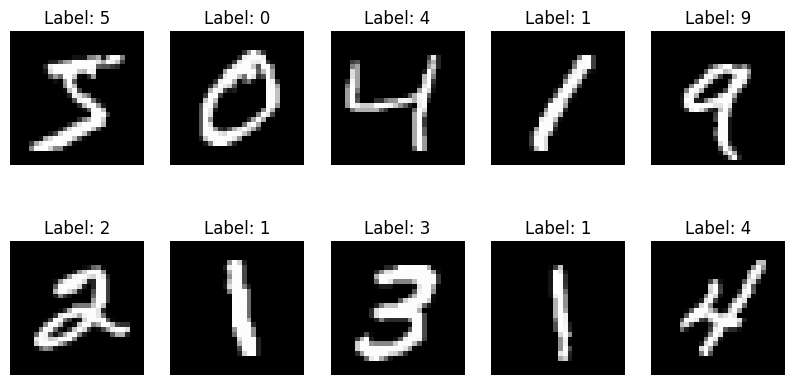

(60000, 28, 28, 1)


In [6]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: " + str(y_train[i]))
    plt.axis("off")

plt.show()
x_train = x_train / 255.0
x_test = x_test / 255.0
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

print(x_train.shape)

In [7]:
model = tf.keras.Sequential([

    # Input image
    tf.keras.layers.Input(shape=(28, 28, 1)),

    # Convolution
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Pooling
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Second convolution
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation='relu'
    ),

    # Second pooling
    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),

    # Convert feature maps to vector
    tf.keras.layers.Flatten(),

    # Fully connected layer
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Output: 10 digits
    tf.keras.layers.Dense(
        10,
        activation='softmax'
    )
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.1
)
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9479 - loss: 0.1744 - val_accuracy: 0.9850 - val_loss: 0.0534
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9832 - loss: 0.0541 - val_accuracy: 0.9852 - val_loss: 0.0527
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9888 - loss: 0.0362 - val_accuracy: 0.9887 - val_loss: 0.0380
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9913 - loss: 0.0272 - val_accuracy: 0.9902 - val_loss: 0.0363
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9932 - loss: 0.0208 - val_accuracy: 0.9883 - val_loss: 0.0403
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9897 - loss: 0.0303
Test Accuracy: 0.9897000193595886


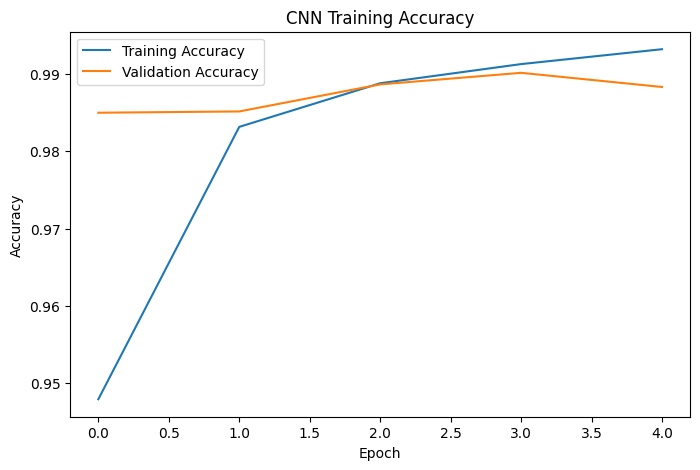

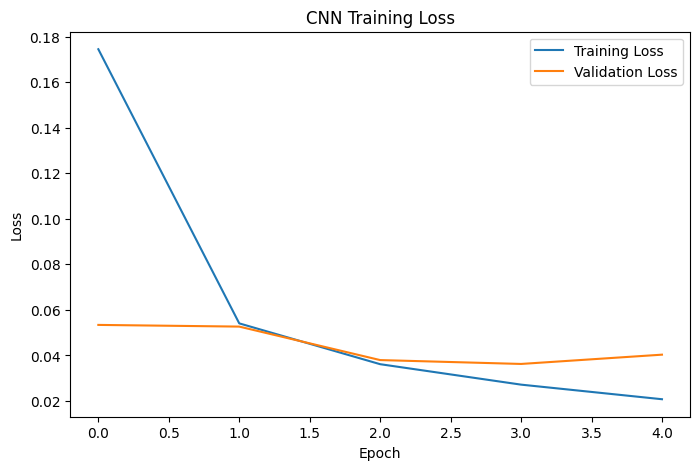

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Training Accuracy")

plt.legend()
plt.show()
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Training Loss")

plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step
Actual digit: 7
Predicted digit: 7


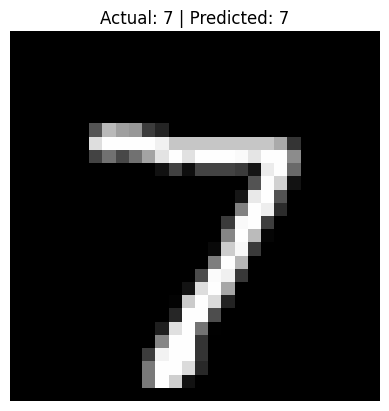

Digit 0: 0.00%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 0.00%
Digit 4: 0.00%
Digit 5: 0.00%
Digit 6: 0.00%
Digit 7: 100.00%
Digit 8: 0.00%
Digit 9: 0.00%


In [10]:
image = x_test[0]

prediction = model.predict(
    np.expand_dims(image, axis=0)
)

predicted_digit = np.argmax(prediction)

print("Actual digit:", y_test[0])
print("Predicted digit:", predicted_digit)
plt.imshow(
    x_test[0].reshape(28, 28),
    cmap='gray'
)

plt.title(
    f"Actual: {y_test[0]} | Predicted: {predicted_digit}"
)

plt.axis("off")
plt.show()
probabilities = prediction[0]

for digit in range(10):
    print(
        f"Digit {digit}: "
        f"{probabilities[digit] * 100:.2f}%"
    )

In [11]:
import numpy as np

# Example of preparing an image for prediction
# Assuming `my_raw_image` is a 2D numpy array (28x28) with pixel values 0-255
# For demonstration, let's use the first test image again.
my_raw_image = x_test[0].reshape(28, 28) * 255.0 # Revert normalization for example

# Step 1: Normalize pixel values to 0-1
normalized_image = my_raw_image / 255.0

# Step 2: Reshape the image to (1, 28, 28, 1)
# The '1' at the beginning indicates a batch size of one image.
# The '1' at the end indicates a single channel (grayscale).
input_image_for_model = np.expand_dims(normalized_image, axis=-1) # Add channel dimension
input_image_for_model = np.expand_dims(input_image_for_model, axis=0) # Add batch dimension

# Alternatively, a more concise way:
# input_image_for_model = normalized_image[np.newaxis, :, :, np.newaxis]

print("Prepared image shape:", input_image_for_model.shape)
print("Prepared image data type:", input_image_for_model.dtype)

# Now you can use this `input_image_for_model` for prediction:
# prediction = model.predict(input_image_for_model)
# predicted_digit = np.argmax(prediction)

Prepared image shape: (1, 28, 28, 1)
Prepared image data type: float64


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


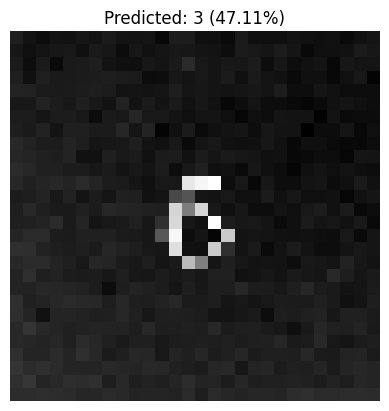

The model thinks this is a: 3


In [13]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# The path to your uploaded image
image_path = '/content/image6.jpg.jpeg'

try:
    # 1. Load the image, convert to grayscale, and resize to 28x28
    img = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(28, 28)
    )

    # 2. Convert to array and normalize (0 to 1)
    # We also invert the colors if your image has a white background and black text,
    # because MNIST (the training data) is white text on a black background.
    img_array = tf.keras.utils.img_to_array(img)

    # Simple check: if the average pixel value is high, it's likely a white background
    if np.mean(img_array) > 127:
        img_array = 255.0 - img_array

    img_array = img_array / 255.0

    # 3. Add batch dimension (1, 28, 28, 1)
    prepared_image = tf.expand_dims(img_array, axis=0)

    # 4. Predict using the trained 'model'
    prediction = model.predict(prepared_image)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # 5. Display Result
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_digit} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"The model thinks this is a: {predicted_digit}")

except Exception as e:
    print(f"Error processing image: {e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


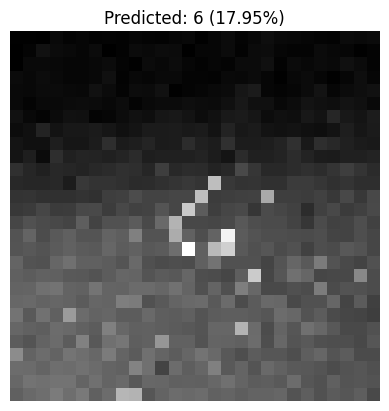

The model thinks this is a: 6


In [17]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# The path to your uploaded image
image_path = '/content/image61.jpeg'

try:
    # 1. Load the image, convert to grayscale, and resize to 28x28
    img = tf.keras.utils.load_img(
        image_path,
        color_mode="grayscale",
        target_size=(28, 28)
    )

    # 2. Convert to array and normalize (0 to 1)
    # We also invert the colors if your image has a white background and black text,
    # because MNIST (the training data) is white text on a black background.
    img_array = tf.keras.utils.img_to_array(img)

    # Simple check: if the average pixel value is high, it's likely a white background
    if np.mean(img_array) > 127:
        img_array = 255.0 - img_array

    img_array = img_array / 255.0

    # 3. Add batch dimension (1, 28, 28, 1)
    prepared_image = tf.expand_dims(img_array, axis=0)

    # 4. Predict using the trained 'model'
    prediction = model.predict(prepared_image)
    predicted_digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # 5. Display Result
    plt.imshow(img_array.reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {predicted_digit} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

    print(f"The model thinks this is a: {predicted_digit}")

except Exception as e:
    print(f"Error processing image: {e}")

In [ ]:
import cv2
import numpy as np

# 1. Load as grayscale directly
img = cv2.imread("/content/image6.jpg.jpeg", cv2.IMREAD_GRAYSCALE)

# 2. Resize to 28x28
img_resized = cv2.resize(img, (28, 28))

# 3. Normalize and add batch/channel dimensions -> shape (1, 28, 28, 1)
prepared_image = img_resized.astype("float32") / 255.0
prepared_image = np.expand_dims(prepared_image, axis=(0, -1))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step


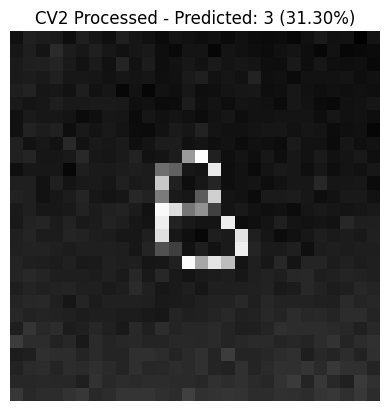

The model predicts the number is: 3


In [16]:
# 4. Ensure the background is dark (invert if it's light)
# MNIST data is white ink on black background.
if np.mean(prepared_image) > 0.5:
    prepared_image = 1.0 - prepared_image

# 5. Predict using the trained model
prediction = model.predict(prepared_image)
predicted_digit = np.argmax(prediction)
confidence = np.max(prediction) * 100

# 6. Display the result
# Converting back to numpy and squeezing out extra dimensions for display
display_img = np.squeeze(prepared_image)

plt.imshow(display_img, cmap='gray')
plt.title(f"CV2 Processed - Predicted: {predicted_digit} ({confidence:.2f}%)")
plt.axis('off')
plt.show()

print(f"The model predicts the number is: {predicted_digit}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


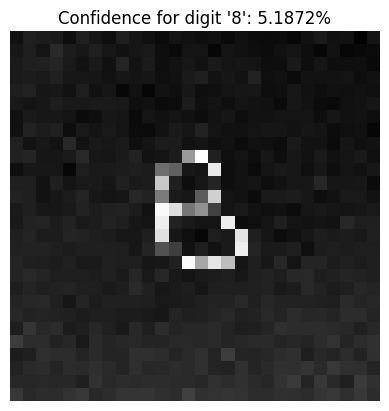

The confidence that the image contains an '8' is 5.1872%
Overall predicted class: 3


In [18]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

image_path_8 = '/content/image8.jpg.jpeg'

try:
    # 1. Load and process image8
    img_8 = tf.keras.utils.load_img(image_path_8, color_mode="grayscale", target_size=(28, 28))
    img_array_8 = tf.keras.utils.img_to_array(img_8)

    # MNIST style check (dark background)
    if np.mean(img_array_8) > 127:
        img_array_8 = 255.0 - img_array_8

    img_array_8 = img_array_8 / 255.0
    prepared_img_8 = tf.expand_dims(img_array_8, axis=0)

    # 2. Predict
    prediction_8 = model.predict(prepared_img_8)

    # 3. Get confidence for character '8' (index 8)
    conf_for_8 = prediction_8[0][8] * 100

    # 4. Display results
    plt.imshow(np.squeeze(img_array_8), cmap='gray')
    plt.title(f"Confidence for digit '8': {conf_for_8:.4f}%")
    plt.axis('off')
    plt.show()

    print(f"The confidence that the image contains an '8' is {conf_for_8:.4f}%")
    print(f"Overall predicted class: {np.argmax(prediction_8)}")

except Exception as e:
    print(f"Error: {e}")